# Neural Networks - Part III

Author: Ethan Robert A. Casin

In this notebook, we'll try to ease into the more practical implementations of deep learning. For the purposes of learning, we'll be using PyTorch as our library in deep learning. Today, we'll try to map what we've learned from a Numpy implementation and what its translation is to PyTorch. 

Our learning objectives today are to:
1. Understand how to implement a typical neural network architecture using Numpy
2. Learn basic PyTorch syntax
3. Familiarize training a standard neural network in PyTorch
4. Learn a standard regularization method in deep learning: drop-out

---

In [1]:
!pip install torch --quiet

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

## Neural Networks Revisited

Let's revisit our neural networks from the previous lecture and even our table.

|$x_1$ | $x_2$ | $\Psi_{\text{AND}}$| $\Psi_{\text{OR}}$| $\Psi_{\text{XOR}}$|
| ---  | ----  |  -----| --- | --- |
| -1   | -1    | 0| 0 | 0|
|-1    | 1     | 0| 1| 1|
|1     | -1    | 0| 1| 1|
|1     | 1     |1 | 1| 0 |

In [3]:
X = np.array(
    [
        [-1, -1],
        [-1, 1],
        [1, -1],
        [1, 1]
    ]
)

y = np.array(
    [
        [0, 0],
        [0, 1],
        [0, 1],
        [1, 0]
    ]
)

The network below was part of a problem set from Part II. There are some changes we want to implement to be more exact on what we do in practice. We'll be assuming you were able to derive the change rules for all weights and biases in the given network. Thus, we'll be focusing on the implementation using Numpy.

Assume that $f(x) = x$, $h(x) = \sin(x)$, and $g(x) = \cos(x)$. The learning rates are arbitrary, so define $\gamma$ appropriately. **The bias is learnable.**

<figure align="center">
<img src="figures/hard-network.png" width="80%">
</figure>

we 4 weights of $w$, 4 wieghts in $v$, and 4 weights for bias

For this discussion and similar sections, we will be using the following cost function

$$E = \frac{1}{2}(\text{pred} - \text{act})^2$$

**Numpy**

Let's define our activation functions and our loss function!

In [4]:
def sin(x, deriv=False):
    if deriv:
        return np.cos(x)
    return np.sin(x)

def cos(x, deriv=False):
    if deriv:
        return -np.sin(x)
    return np.cos(x)

def loss_fn(pred, act, deriv=False):
    if deriv:
        return pred - act
    return (1/2) * (pred - act)**2

Afterwards, we can now recreate our neural network.

In [9]:
n_input_nodes = 2
n_hidden_nodes = 2
n_output_nodes = 2

n_iters = int(1e4)

learning_rate = 0.001

# Randomly initialize weights and biases

## Input to hidden 
W = 2 * np.random.random((n_input_nodes, n_hidden_nodes)) - 1
# we have -1 to force it into a normal distribution
Bih = 2 * np.random.random((n_hidden_nodes,)) - 1

## Hidden to output
V = 2 * np.random.random((n_hidden_nodes, n_output_nodes)) - 1
Bho = 2 * np.random.random((n_output_nodes,)) - 1


# Train the network
for i in range(n_iters):
    layer0 = X
    
    layer1_input = np.dot(layer0, W) + Bih
    layer1 = sin(layer1_input)

    layer2_input = np.dot(layer1, V) + Bho
    layer2 = cos(layer2_input)

    loss = loss_fn(layer2, y)
    if (i % 1000) == 0:
        print(f"Mean Absolute Loss: {np.mean(np.abs(loss)):.4f}")

    # Do the gradient descent
    grad = loss_fn(layer2, y, deriv=True)
    print(grad)
    layer2_delta = grad * cos(layer2_input, deriv=True)
    layer1_delta = layer2_delta.dot(V.T) * sin(layer1_input, deriv=True)

    V -= learning_rate * layer1.T.dot(layer2_delta)
    Bho -= learning_rate * layer2_delta.sum(axis=0)

    W -= learning_rate * layer0.T.dot(layer1_delta)
    Bih -= learning_rate * layer1_delta.sum(axis=0)


y_preds = np.rint(layer2)
print("=" * 50)
print("Raw Output after training:\n")
print(layer2)
print("Learned weights:\n")
print(f"{W=}")
print(f"{V=}")
print("Learned biases:\n")
print(f"{Bih=}")
print(f"{Bho=}")
print("-" * 50)

print(f"Thresholded result at 0.5:\n{y_preds}")
print(f"Actual:\n{y}")
print(f"Accuracy: {accuracy_score(y, y_preds) * 100:.2f}%")

Mean Absolute Loss: 0.1943
[[ 0.72430298  0.79467452]
 [ 0.28132384 -0.62965148]
 [ 0.93277958 -0.03494282]
 [-0.46139881  0.62622893]]
[[ 0.72268067  0.79355478]
 [ 0.28041096 -0.62994169]
 [ 0.93204061 -0.03538098]
 [-0.46200338  0.62608001]]
[[ 0.72105402  0.79243263]
 [ 0.27949854 -0.63023142]
 [ 0.93129661 -0.03582225]
 [-0.46260799  0.62593126]]
[[ 0.71942305  0.79130813]
 [ 0.27858659 -0.63052067]
 [ 0.9305476  -0.03626664]
 [-0.46321263  0.62578269]]
[[ 0.71778782  0.7901813 ]
 [ 0.27767514 -0.63080942]
 [ 0.92979356 -0.03671413]
 [-0.4638173   0.6256343 ]]
[[ 0.71614838  0.78905217]
 [ 0.27676421 -0.63109767]
 [ 0.92903451 -0.03716473]
 [-0.46442197  0.62548609]]
[[ 0.71450478  0.78792078]
 [ 0.27585381 -0.63138539]
 [ 0.92827043 -0.03761844]
 [-0.46502665  0.62533807]]
[[ 0.71285705  0.78678717]
 [ 0.27494396 -0.63167258]
 [ 0.92750135 -0.03807525]
 [-0.46563131  0.62519024]]
[[ 0.71120525  0.78565136]
 [ 0.27403469 -0.63195923]
 [ 0.92672725 -0.03853516]
 [-0.46623596  0.625

A key skill that we'll be learning more of is counting the parameters of a given architecture. This will be asked all throughout the succeeding lectures, so make sure you understand how we count the number of parameters!

---

**Question**: How many learned parameters do we have?<br>

**Question**: What can you infer from our gradients per run? Talk about a scenario if we implemented our `grad` variable incorrectly. What would it look like and what's the consequence?


grad has values. we are overriding the gradient (not append the gradient). We do not just add values to the gradient because you should not be relying on previous iterations since the network will have a wrong impression on their targets. you want them to be independent on that run. 
---

**PyTorch**

In the deep learning world there are two main libraries for implementation: PyTorch and TensorFlow. Each library has its pros and cons, but the biggest benefit of PyTorch for us is that:
1. It's modular enough for us to understand how to do certain elements from scratch;
2. It is commonly used in machine learning research over tensorflow;
3. It is can help facilitate our learning transition from Numpy to an actual deep learning framework
4. GPU executions

TDD is test-driven-development. For work, tensorflow is the built in standard since it is super convenient and scalable. The problem is that when it comes to teaching, it is not as good since it abstracts away all the aspects. PyTorch is the standard for research papers. PyTorch explicitly defines where you are running your models.

There is this object called an `accelerator` in PyTorch. This is essentially the compute type you'll be using. By default, PyTorch would use your `cpu` to do its calculations. For the purposes of learning how to integrate GPUs for deep learning, we can try to learn how to use them in this notebook. If you're using Jojie, the `print` statement below will say `cuda:0` which means it's using an NVIDIA GPU.

In [10]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


To avoid any confusion, we'll redefine our `loss_fn` to fit the syntax of PyTorch. 

In [11]:
def torch_loss_fn(pred, act):
    # Mean squared error
    return (1/2) * (pred - act).pow(2).mean()

There is one important thing to be understand about PyTorch and it's the usage of `tensors`. In mathematics, we generally define a tensor as a matrix having 3 or more dimensions (rank >2). So keep in mind that PyTorch, and subsequently TensorFlow, use `tensors` instead of `arrays`. Mathematically these are similar, but defined differently. But there's not a lot of differences in coding.

A tensor is a more general form of a matrix since you scale it up or down. Let us now convert our numpy code to pytorch

In [ ]:
n_input_nodes = 2
n_hidden_nodes = 2
n_output_nodes = 2

dtype = torch.float # best practice to always define the data type

n_iters = int(1e4)

# you have to define the datatype all the time
# if you are using a gpu, you have to define the device
# when dealing with a small dataset, dont use a GPU because there is overhead and the lag of moving things around
# when dealing with a large dataset, use a GPU
X_tensor = torch.tensor(X, dtype=dtype, device=device)
y_tensor = torch.tensor(y, dtype=dtype, device=device)

learning_rate = 0.001


# Randomly initialize weights and biases

## Input to hidden 
# pytorch will compute the derivative for you automatically thru auto_grad
# you will always have to define if it is differentiable or not thru requires_grad
W_tensor = torch.randn(
    (n_input_nodes, n_hidden_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bih_tensor = torch.randn(
    (n_hidden_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

## Hidden to output
V_tensor = torch.randn(
    (n_hidden_nodes, n_output_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bho_tensor = torch.randn(
    (n_output_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

for i in range(n_iters):
    layer0 = X_tensor
    layer1_input = torch.matmul(layer0, W_tensor) + Bih_tensor
    layer1 = torch.sin(layer1_input)

    layer2_input = torch.matmul(layer1, V_tensor) + Bho_tensor
    layer2 = torch.cos(layer2_input)

    loss = torch_loss_fn(layer2, y_tensor)

    # Now, we'll use the autograd feature of PyTorch
    # to compute for the gradients automatically.
    # Because we declared that gradients are required for all of our
    # tensors, we simply call the backward() method from our loss function
    # Note: the output from our loss_fn is also a tensor, which has this method
    loss.backward()

    # Let's first manually update our weights
    with torch.no_grad():
        V_tensor -= learning_rate * V_tensor.grad
        Bho_tensor -= learning_rate * Bho_tensor.grad

        W_tensor -= learning_rate * W_tensor.grad
        Bih_tensor -= learning_rate * Bih_tensor.grad

        # From our code right now, we need to manually reset our gradients.
        # We do this to ensure that our gradients don't accumulate. PyTorch
        # saves the gradients for each iteration by default, so you'll need to reset them
        V_tensor.grad = None
        W_tensor.grad = None
        Bho_tensor.grad = None
        Bih_tensor.grad = None

y_preds = torch.round(layer2)
print("=" * 50)
print("Raw Output after training:\n")
print(layer2)
print("Learned weights:\n")
print(f"{W_tensor=}")
print(f"{V_tensor=}")
print("Learned biases:\n")
print(f"{Bih_tensor=}")
print(f"{Bho_tensor=}")
print("-" * 50)

print(f"Thresholded result at 0.5:\n{y_preds}")
print(f"Actual:\n{y_tensor}")
print(f"Accuracy: {torch.sum(y_tensor == y_preds, dim=0) / y_preds.size(0) * 100}")

# You can comment the code below to have this and our numpy code more comparable
# print(f"Accuracy: {accuracy_score(y_tensor.cpu().detach().numpy(), y_preds.cpu().detach().numpy()) * 100:.2f}%")


Raw Output after training:

tensor([[-0.0672,  0.1058],
        [ 0.0833,  0.9793],
        [ 0.0371,  0.8882],
        [ 0.8783,  0.0066]], device='mps:0', grad_fn=<CosBackward0>)
Learned weights:

W_tensor=tensor([[ 0.4036, -0.5312],
        [ 0.4552, -0.7278]], device='mps:0', requires_grad=True)
V_tensor=tensor([[ 1.6200, -0.5131],
        [ 0.1244, -1.8850]], device='mps:0', requires_grad=True)
Learned biases:

Bih_tensor=tensor([-0.9791,  0.2656], device='mps:0', requires_grad=True)
Bho_tensor=tensor([-0.1998, -0.0768], device='mps:0', requires_grad=True)
--------------------------------------------------
Thresholded result at 0.5:
tensor([[-0., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.]], device='mps:0', grad_fn=<RoundBackward0>)
Actual:
tensor([[0., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.]], device='mps:0')
Accuracy: tensor([100., 100.], device='mps:0')


### Epochs

---

**Question**: What is an epoch?

---

In [8]:
n_input_nodes = 2
n_hidden_nodes = 2
n_output_nodes = 2

dtype = torch.float # best practice to always define the data type

n_epochs = int(1e4) # this is basically how many epochs

X_tensor = torch.tensor(X, dtype=dtype, device=device)
y_tensor = torch.tensor(y, dtype=dtype, device=device)

learning_rate = 0.001


# Randomly initialize weights and biases

## Input to hidden 
W_tensor = torch.randn(
    (n_input_nodes, n_hidden_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bih_tensor = torch.randn(
    (n_hidden_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

## Hidden to output
V_tensor = torch.randn(
    (n_hidden_nodes, n_output_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bho_tensor = torch.randn(
    (n_output_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

for epoch in range(n_epochs):
    layer0 = X_tensor
    layer1_input = torch.matmul(layer0, W_tensor) + Bih_tensor
    layer1 = torch.sin(layer1_input)

    layer2_input = torch.matmul(layer1, V_tensor) + Bho_tensor
    layer2 = torch.cos(layer2_input)

    loss = torch_loss_fn(layer2, y_tensor)

    # Now, we'll use the autograd feature of PyTorch
    # to compute for the gradients automatically.
    # Because we declared that gradients are required for all of our
    # tensors, we simply call the backward() method from our loss function
    # Note: the output from our loss_fn is also a tensor, which has this method
    loss.backward()

    # Let's first manually update our weights
    with torch.no_grad():
        V_tensor -= learning_rate * V_tensor.grad
        Bho_tensor -= learning_rate * Bho_tensor.grad

        W_tensor -= learning_rate * W_tensor.grad
        Bih_tensor -= learning_rate * Bih_tensor.grad

        # From our code right now, we need to manually reset our gradients.
        # We do this to ensure that our gradients don't accumulate. PyTorch
        # saves the gradients for each iteration by default, so you'll need to reset them
        V_tensor.grad = None
        W_tensor.grad = None
        Bho_tensor.grad = None
        Bih_tensor.grad = None

y_preds = torch.round(layer2)
print("=" * 50)
print("Raw Output after training:\n")
print(layer2)
print("Learned weights:\n")
print(f"{W_tensor=}")
print(f"{V_tensor=}")
print("Learned biases:\n")
print(f"{Bih_tensor=}")
print(f"{Bho_tensor=}")
print("-" * 50)

print(f"Thresholded result at 0.5:\n{y_preds}")
print(f"Actual:\n{y_tensor}")
print(f"Accuracy: {torch.sum(y_tensor == y_preds, dim=0) / y_preds.size(0) * 100}")

# You can comment the code below to have this and our numpy code more comparable
# print(f"Accuracy: {accuracy_score(y_tensor.cpu().detach().numpy(), y_preds.cpu().detach().numpy()) * 100:.2f}%")


Raw Output after training:

tensor([[ 0.0429,  0.1390],
        [-0.0083,  0.9445],
        [-0.0823,  0.7698],
        [ 0.9616,  0.0111]], device='mps:0', grad_fn=<CosBackward0>)
Learned weights:

W_tensor=tensor([[ 1.1223, -1.2289],
        [-1.0801, -2.5461]], device='mps:0', requires_grad=True)
V_tensor=tensor([[1.1961, 0.9708],
        [1.2127, 0.0830]], device='mps:0', requires_grad=True)
Learned biases:

Bih_tensor=tensor([ 0.9641, -0.5906], device='mps:0', requires_grad=True)
Bho_tensor=tensor([-2.4290,  0.6614], device='mps:0', requires_grad=True)
--------------------------------------------------
Thresholded result at 0.5:
tensor([[0., 0.],
        [-0., 1.],
        [-0., 1.],
        [1., 0.]], device='mps:0', grad_fn=<RoundBackward0>)
Actual:
tensor([[0., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.]], device='mps:0')
Accuracy: tensor([100., 100.], device='mps:0')


## Stochastic Gradient Descent

What we've learned so far in backpropagation is gradient descent. To be more accurate, what we're doing right now in backpropagation is called **batch gradient descent**. The idea of this type of gradient descent is to feed the entire training set when doing backpropagation. As you can guess by now, it's not to scale. Another aspect of this type of gradient descent is that it takes a while to converge, and in some papers, found that it can get stuck in "bad" local minima/maxima. 

In order to overcome this, instead of using the entire training set when optimizing we can simply get samples or small batches of the training data. The purest form of stochastic gradient descent is to use certain samples from the training set. 

Suppose that we have the objective function $Q(w) = \frac{1}{2}\sum_i^nQ_i(w)$ that we'll use to perform gradient descent on for all $n$ outputs. We define $Q_i(w)$
as the value of the loss function at the $i$-th example. Given a learning rate $\alpha$, the **batch gradient descent** method would be defined as 

$$w^{t+1} = w^t - \alpha\nabla Q(w^t) = w^t - \frac{\alpha}{2}\sum_i^nQ_i(w^t)$$


**Stochastic gradient descent** (SGD), on the other hand, uses a single sample or a mini batch of samples (a.k.a., mini-batch gradient descent) in order to overcome the limitations of batch gradient descent. On average, SGD tends to be faster because it is using only a small subset of data to optimize the network. So, given our definition of the update rule above, the SGD version of it would look like

$$w^{t+1} = w^t - \alpha\nabla Q_i(w^t) $$

In practice, we don't use a single sample for SGD. Instead we typically use mini-batch gradient descent for better generalization and less sensitivity to noise. Let's implement this from scratch using PyTorch!

In [12]:
import math

In [13]:
X_periodic = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=torch.float).unsqueeze(1)
y_periodic = torch.sin(X_periodic)

In [15]:
n_input_nodes = 1
n_hidden_nodes = 2
n_output_nodes = 1

dtype = torch.float # best practice to always define the data type

n_epochs = int(1e4) # this is basically how many epochs

learning_rate = 0.001


# Randomly initialize weights and biases

## Input to hidden 
W_tensor = torch.randn(
    (n_input_nodes, n_hidden_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bih_tensor = torch.randn(
    (n_hidden_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

## Hidden to output
V_tensor = torch.randn(
    (n_hidden_nodes, n_output_nodes),
    device=device,
    dtype=dtype,
    requires_grad=True,
)
Bho_tensor = torch.randn(
    (n_output_nodes,),
    device=device,
    dtype=dtype,
    requires_grad=True,
)

n_samples = X_periodic.size(0)
batch_size = 100 # we get 100 random points

for epoch in range(n_epochs):

    # Select a random batch of points (start of SGD), a problem with this SGD is because you are not using everything
    batch_indx = torch.randint(
        low=0,
        high=n_samples,
        size=(batch_size,),
        device=device,
    )

    X_batch = X_periodic[batch_indx]
    y_batch = y_periodic[batch_indx]
    # End of SGD
    
    layer0 = X_batch
    layer1_input = torch.matmul(layer0, W_tensor) + Bih_tensor
    layer1 = torch.sin(layer1_input)

    layer2_input = torch.matmul(layer1, V_tensor) + Bho_tensor
    layer2 = torch.cos(layer2_input)

    loss = torch_loss_fn(layer2, y_batch)

    # Now, we'll use the autograd feature of PyTorch
    # to compute for the gradients automatically.
    # Because we declared that gradients are required for all of our
    # tensors, we simply call the backward() method from our loss function
    # Note: the output from our loss_fn is also a tensor, which has this method
    loss.backward()

    # Let's first manually update our weights
    with torch.no_grad():
        V_tensor -= learning_rate * V_tensor.grad
        Bho_tensor -= learning_rate * Bho_tensor.grad

        W_tensor -= learning_rate * W_tensor.grad
        Bih_tensor -= learning_rate * Bih_tensor.grad

        # From our code right now, we need to manually reset our gradients.
        # We do this to ensure that our gradients don't accumulate. PyTorch
        # saves the gradients for each iteration by default, so you'll need to reset them
        V_tensor.grad = None
        W_tensor.grad = None
        Bho_tensor.grad = None
        Bih_tensor.grad = None

# Because we trained our network in mini-batches, taking out the last layer now
# would result in a size mismatch error.
# We therefore need to do a forward pass on the entire dataset using the trained network

with torch.no_grad():
    layer0 = X_periodic
    layer1_input = torch.matmul(layer0, W_tensor) + Bih_tensor
    layer1 = torch.sin(layer1_input)

    layer2_input = torch.matmul(layer1, V_tensor) + Bho_tensor
    y_preds = torch.cos(layer2_input)


print("=" * 50)
print("Predictions:\n")
print(y_preds)
print("Learned weights:\n")
print(f"{W_tensor=}")
print(f"{V_tensor=}")
print("Learned biases:\n")
print(f"{Bih_tensor=}")
print(f"{Bho_tensor=}")
print("-" * 50)

print(f"Actual:\n{y_periodic}")
print(f"MSE: {torch.mean((y_periodic - y_preds) ** 2)}")

Predictions:

tensor([[-0.0782],
        [-0.0816],
        [-0.0850],
        ...,
        [ 0.3447],
        [ 0.3446],
        [ 0.3446]], device='mps:0')
Learned weights:

W_tensor=tensor([[ 0.6698, -0.0096]], device='mps:0', requires_grad=True)
V_tensor=tensor([[-1.8831],
        [ 1.4184]], device='mps:0', requires_grad=True)
Learned biases:

Bih_tensor=tensor([-0.5361,  0.3776], device='mps:0', requires_grad=True)
Bho_tensor=tensor([0.1813], device='mps:0', requires_grad=True)
--------------------------------------------------
Actual:
tensor([[ 8.7423e-08],
        [-3.1430e-03],
        [-6.2863e-03],
        ...,
        [ 6.2860e-03],
        [ 3.1432e-03],
        [-8.7423e-08]], device='mps:0')
MSE: 0.008809870108962059


---

**Question**: What was the biggest flaw of our SGD implementation above?

---

## Formal Examples

So far, we haven't really did a formal implementation of a neural network in practice. We're still kinda sticking to what we know. This section will now introduce you to a formal definition of neural networks using PyTorch. 

If I haven't emphasized this enough in our previous lectures, the main way to create our neural networks is through object-oriented programming (OOP). This is true for both PyTorch and Tensorflow. We'll also get acquainted with some typical functions we use when creating models which are shown below.

In [16]:
from torch import nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

The main thing to know about these imports for now are:
- `nn` is our main module when constructing our neural network.
- `optim` contains our gradient descent methods, such as SGD and Adam
- `torch.utils.data` contain important methods for endorsing datasets to PyTorch and in creating our mini-batches for training

Let' create a small neural network called `SimpleNetwork` using PyTorch.

wehen creating a neural network, you have to use OOP. linear just means a linear combination. for every neural netowork, you have to define a forward method.

In [19]:
class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_hidden = nn.Linear(1, 10)
        self.hidden_out = nn.Linear(10, 1)

    def forward(self, X):
        layer0 = self.input_hidden(X)
        layer1 = torch.tanh(layer0)
        layer2 = self.hidden_out(layer1)
        return layer2

Every PyTorch class should have the `init` and `forward` methods. The `nn.Module` contains a couple of abstractions for us to use during training and inference. We'll then convert our `X_periodic` and `y_periodic` into a PyTorch `TensorDataset`. We then pass this to a `DataLoader`, which will help us in creating our mini-batches as indicated by `batch_size`. 

*Note: `batch_size` typically ranges from 32 - 1024.*

In [20]:
dataset = TensorDataset(X_periodic, y_periodic)
train_loader = DataLoader(dataset, batch_size=100, shuffle=True)

Epoch 100, Loss: 0.1071
Epoch 200, Loss: 0.0880
Epoch 300, Loss: 0.0718
Epoch 400, Loss: 0.0584
Epoch 500, Loss: 0.0471
Epoch 600, Loss: 0.0376
Epoch 700, Loss: 0.0308
Epoch 800, Loss: 0.0264
Epoch 900, Loss: 0.0237
Epoch 1000, Loss: 0.0220

Predictions:
tensor([[-0.3996],
        [-0.4004],
        [-0.4012],
        ...,
        [ 0.4621],
        [ 0.4614],
        [ 0.4608]], device='mps:0')


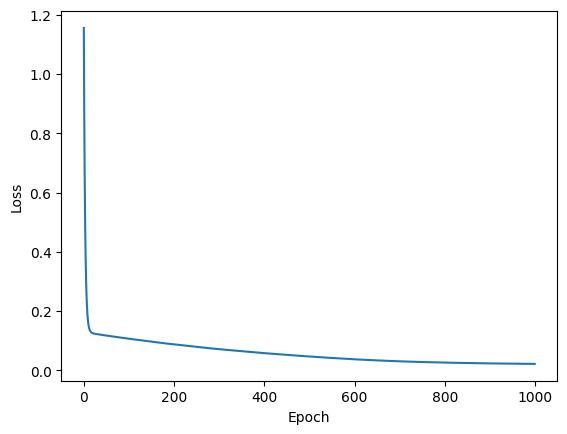

In [ ]:
# We define our model, loss function, and optimizer
model1 = SimpleNetwork().to(device) # We'll place it in our GPU if you have it
criterion = nn.MSELoss()            # Our loss function
optimizer = optim.SGD(model1.parameters(), lr=0.001)  # Our gradient descent method

epochs = 1000
loss_res_sgd = [] # save the training loss

# we'll need this to get the average loss per epoch
n_batches = len(train_loader) 

for epoch in range(epochs):
    running_loss = 0.0
    model1.train() # important to set for training

    # you make the model learn for each batch, the optimizer would then move the next step/gradient
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model1(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_loss = running_loss / n_batches
    loss_res_sgd.append(epoch_loss)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

print("\nPredictions:")
# detach is forcing pytorch not to log any gradients
# automatically, pytorch will log something
# pytorch is more like C and it will tell you where it is your tensors and the such
print(model1(X_periodic).detach())

plt.plot(loss_res_sgd)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

*Note: the `detach()` method tries to remove the tensor from the current computational graph. Doing this ensures that any operations done on this tensor will not be tracked by `autograd`.*

### Adam Optimizer

Now You may notice the name `Adam` come out a lot in deep learning. `Adam` is essentially the gradient descent method we're using. If you'll notice earlier, SGD and our batch gradient descent can take long to compute and the learning rate is fixed throughout. `Adam`, which is named after *adaptive momentum* improves on current gradient descent methods to have dynamic learning rates and a more efficient performance.

Although talking about `Adam` will take a while, I'll be providing the four most commonly used optimizers for deep learning. Yes, SGD is not used as much in practice anymore, but it is important to understand SGD for us to know how we got to this point.


| Optimizer          | Use When                                                | Pros                             | Cons                           |
| ------------------ | ------------------------------------------------------- | -------------------------------- | ------------------------------ |
| **AdaGrad**        | Sparse features (classical NLP)                         | Adaptive, no tuning              | LR decays to zero              |
| **RMSProp**        | RL, RNNs                                                | Handles non-stationary gradients | Noisy, less stable than Adam   |
| **Adam**           | Most modern DL (NLP, transformers, generative models)   | Fast, stable, adaptive           | Sometimes worse generalization |
| **Adamax**         | Extreme gradient spikes                                 | Very stable                      | Rarely needed                  |

*Note: table formatting and summarization of pros and cons were done through ChatGPT*

Epoch 100, Loss: 0.0215
Epoch 200, Loss: 0.0033
Epoch 300, Loss: 0.0001
Epoch 400, Loss: 0.0000
Epoch 500, Loss: 0.0000
Epoch 600, Loss: 0.0000
Epoch 700, Loss: 0.0000
Epoch 800, Loss: 0.0000
Epoch 900, Loss: 0.0000
Epoch 1000, Loss: 0.0000

Predictions:
tensor([[ 0.0015],
        [-0.0016],
        [-0.0048],
        ...,
        [ 0.0142],
        [ 0.0113],
        [ 0.0084]], device='mps:0')


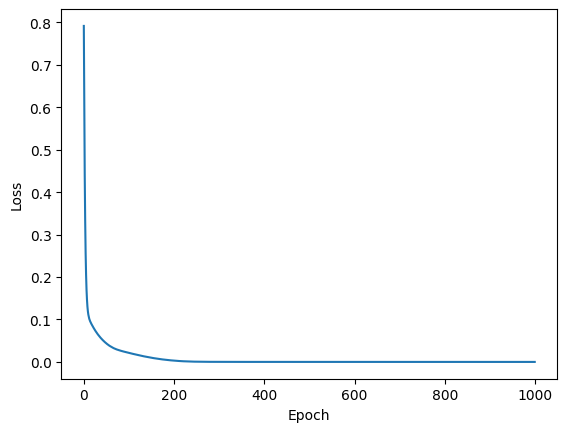

In [22]:
model2 = SimpleNetwork().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

epochs = 1000
loss_res_adam = []

for epoch in range(epochs):
    running_loss = 0.0
    model2.train() # important to set for training

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model2(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_loss = running_loss / n_batches
    loss_res_adam.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print("\nPredictions:")
final_preds = model2(X_periodic).detach()
print(final_preds)

plt.plot(loss_res_adam)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

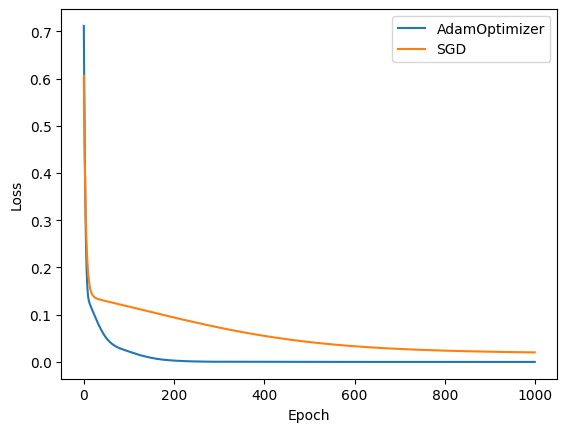

In [17]:
plt.plot(loss_res_adam, label="AdamOptimizer")
plt.plot(loss_res_sgd, label="SGD")

plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

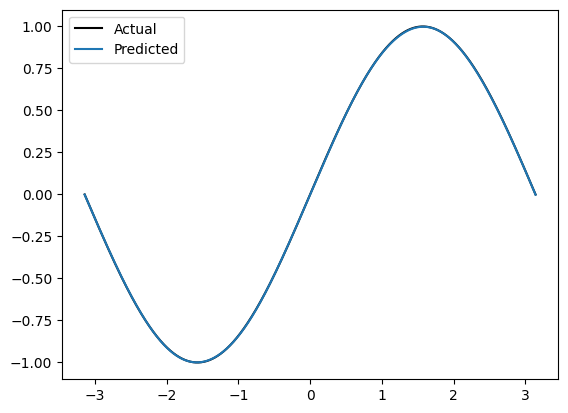

In [18]:
plt.plot(X_periodic.cpu(), y_periodic.cpu(), label="Actual", c="black")
plt.plot(X_periodic.cpu(), final_preds.cpu(), label="Predicted")
plt.legend()
plt.show()

### Dropout

---

**Question**: Why do we need to use dropouts?

---


One of the ways neural networks fail is when we repeatedly try to train our networks we encounter a phenomenon called **co-adaptation**. This happens when your nodes become highly dependent on each other. The consequence of this is that the neuron would not learn a feature that would help produce the correct answer. In other words, it leads the models to *overfitting*.

A common way to combat this is through regularization, and it was found that for neural networks we can randomly "drop" neurons during training to allow the other nodes to learn from the feature space. This is called a **dropout**. 

In general, dropouts are placed on each layer of the network except the output layer. For each epoch in training, we randomly disable neurons from each layer with a probability $p$. Typically, $p$ is chosen in the range of 0.1 - 0.5, where the most common choice is 0.2. Effectively we create and train smaller networks on each epoch, leading our nodes to learn useful feature patterns that would contribute to the overall result.

Once we're done with training and ready for inference, we disable our dropouts. This ensures we're using the entire network to conduct inference on our output. Let's implement our final network by including a `Dropout` layer.



In [19]:
class NeuralNet(nn.Module):
    def __init__(
        self,
        input_dim,
        n_hidden_layers,
        n_hidden_nodes,
        n_output_nodes,
        dropout_rate=0.2,
    ):
        super().__init__()

        # Construct the network
        layers = [nn.Linear(input_dim, n_hidden_nodes), nn.ReLU(), nn.Dropout(dropout_rate)]
        for h in range(n_hidden_layers):
            layers.extend(
                [nn.Linear(n_hidden_nodes, n_hidden_nodes), nn.ReLU(), nn.Dropout(dropout_rate)]
            )

        # For our current task, we don't need to include a ReLU at the end, because
        # we want our output values to be (-∞, +∞)
        layers.append(nn.Linear(n_hidden_nodes, n_output_nodes))

        self.network = nn.Sequential(*layers)
    
    def forward(self, X):
        return self.network(X)

In [20]:
# Generate new data
X_new = torch.linspace(
    -2 * math.pi, 2 * math.pi, 2000, device=device, dtype=torch.float
).unsqueeze(1)
y_new = torch.sin(X_new) + torch.rand(X_new.size(0), X_new.size(1), device=device)

# Train test split
train_size = int(0.8 * X_new.size(0))
test_size = X_new.size(0) - train_size

training, testing = torch.utils.data.random_split(
    TensorDataset(X_new, y_new), [train_size, test_size]
)

# Define your data loaders
train_loader = DataLoader(training, batch_size=100, shuffle=True)
test_loader = DataLoader(testing, batch_size=100, shuffle=False) # we want to evaluate with order intact

In [21]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, show_grad=False):
    criterion =  nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    n_trainloader = len(train_loader)
    n_valloader = len(val_loader)
    
    # Model training
    for epoch in  range(epochs):
        model.train()
        running_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
                
            # Print gradients
            if show_grad:
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        print(f"{name}: grad_norm = {param.grad.norm().item():.6f}")
            optimizer.step()
            running_loss += loss.item()
    
        train_losses.append(running_loss / n_trainloader)
    
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for X_val, y_val in val_loader:
                preds = model(X_val)
                # no need to do backpropagation for inference
                vloss = criterion(preds, y_val)
                val_loss += vloss.item()
            val_losses.append(val_loss / n_valloader)
    return train_losses, val_losses

---

**Question:** What's the importance of viewing the gradients?

---

In [24]:
new_model = NeuralNet(
    input_dim=X_new.size(1),
    n_hidden_layers=3,
    n_hidden_nodes=10,
    n_output_nodes=1,
    dropout_rate=0.2,
).to(device)

train_loss, test_loss = train_model(new_model, train_loader, test_loader, show_grad=False)

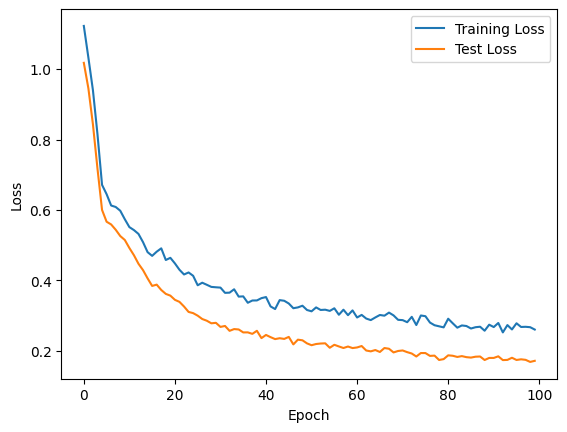

In [25]:
plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()